<a href="https://colab.research.google.com/github/karanja-dave/crop_disease_prediction_CNN/blob/jedy/Capstone_EDA_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shubham2703/five-crop-diseases-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'five-crop-diseases-dataset' dataset.
Path to dataset files: /kaggle/input/five-crop-diseases-dataset


In [16]:
import os
from pathlib import Path

# Update the path based on your kagglehub output
new_path = Path(path)

# List the top-level directories to find where the images live
print("Top level folders:", [f.name for f in new_path.iterdir() if f.is_dir()])


Top level folders: ['Crop Diseases Dataset']


Total images found: 13324


Checking dimensions: 100%|██████████| 2000/2000 [00:11<00:00, 174.33it/s]


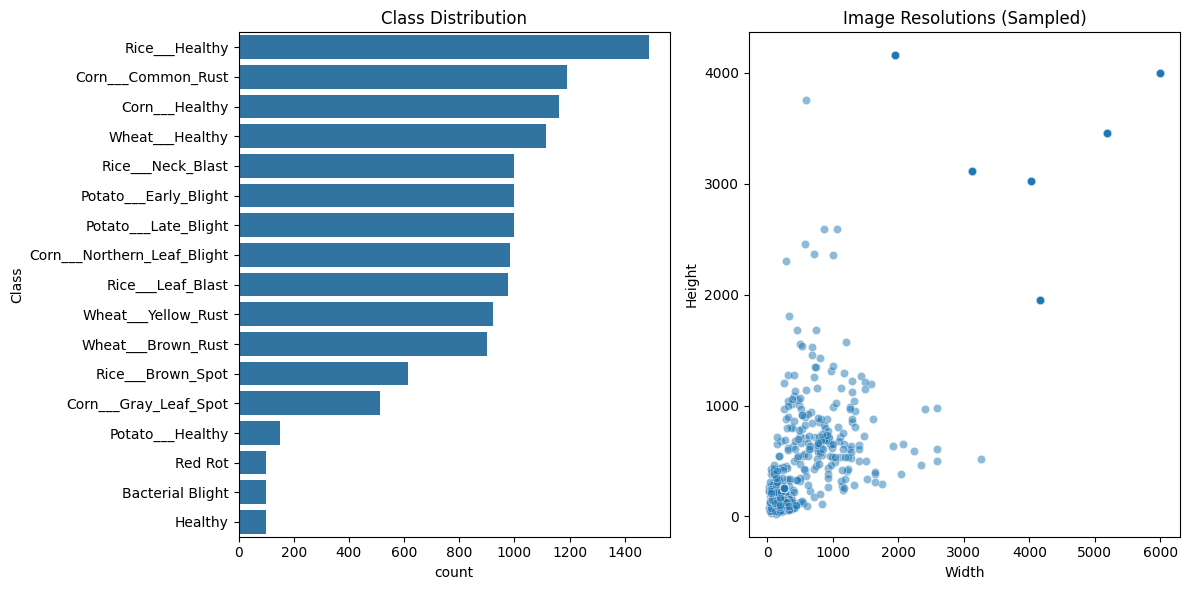

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

# 1. Map all files
all_files = list(new_path.glob('**/*.[jJ][pP][gG]'))
print(f"Total images found: {len(all_files)}")

# 2. Fast metadata extraction (Sampling 2000 images for dimension check)
metadata = []
sample_size = min(2000, len(all_files))
import random
sample_files = random.sample(all_files, sample_size)

for img_path in tqdm(sample_files, desc="Checking dimensions"):
    try:
        with Image.open(img_path) as img:
            metadata.append({
                'Class': img_path.parent.name,
                'Width': img.size[0],
                'Height': img.size[1]
            })
    except:
        continue

# 3. Full Class Count (using all files for accuracy)
all_labels = [f.parent.name for f in all_files]
df_labels = pd.DataFrame(all_labels, columns=['Class'])
df_meta = pd.DataFrame(metadata)

# --- Visualizations ---
plt.figure(figsize=(12, 6))

# Class Distribution
plt.subplot(1, 2, 1)
sns.countplot(data=df_labels, y='Class', order=df_labels['Class'].value_counts().index)
plt.title('Class Distribution')

# Dimension Consistency
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_meta, x='Width', y='Height', alpha=0.5)
plt.title('Image Resolutions (Sampled)')

plt.tight_layout()
plt.show()


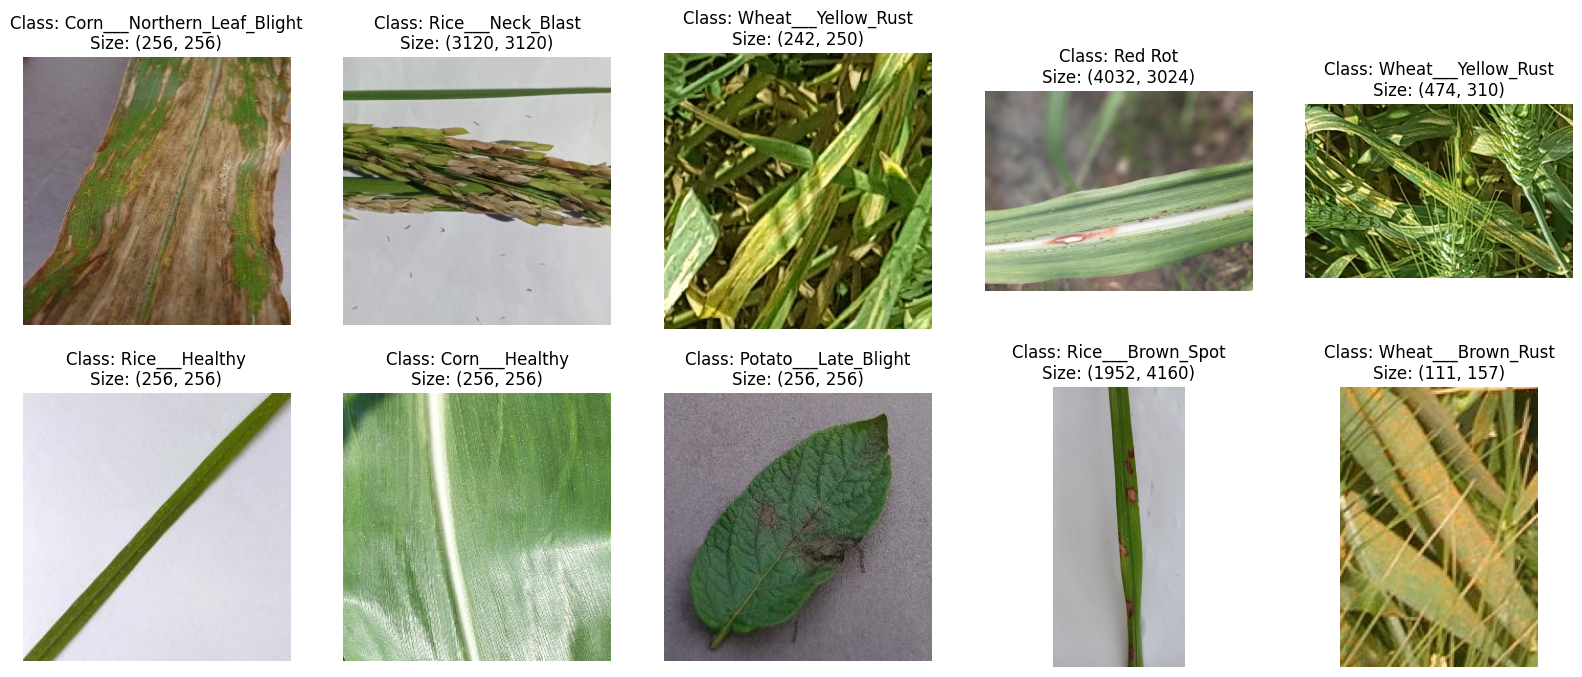

In [18]:
import random
import matplotlib.pyplot as plt
from PIL import Image

def plot_random_samples(image_list, num=10):
    plt.figure(figsize=(20, 8))
    samples = random.sample(image_list, num)
    for i, img_path in enumerate(samples):
        plt.subplot(2, 5, i+1)
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(f"Class: {img_path.parent.name}\nSize: {img.size}")
        plt.axis('off')
    plt.show()

plot_random_samples(all_files)


In [19]:
df_meta['Aspect_Ratio'] = df_meta['Width'] / df_meta['Height']
print(df_meta['Aspect_Ratio'].value_counts().head())


Aspect_Ratio
1.000000    1466
1.500000      40
0.469231      27
2.131148      16
1.333333      10
Name: count, dtype: int64


In [20]:
import tensorflow as tf

# 1. Define image parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# 2. Load and Preprocess
# 'smart_resize' prevents the "squish" by cropping the center of rectangular images
train_ds = tf.keras.utils.image_dataset_from_directory(
    new_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    crop_to_aspect_ratio=True # <--- CRITICAL for your mixed aspect ratios
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    new_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    crop_to_aspect_ratio=True
)

# 3. Add Data Augmentation to handle different backgrounds
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomContrast(0.1),
])

# Apply augmentation to the training set
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# 4. Optimize Performance (Pre-fetching into RAM)
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)


Found 13324 files belonging to 1 classes.
Using 10660 files for training.
Found 13324 files belonging to 1 classes.
Using 2664 files for validation.


In [21]:
# Check which folder actually contains the disease subdirectories
import os
for root, dirs, files in os.walk(new_path):
    if len(dirs) > 1:
        print(f"✅ FOUND THE CORRECT DATA DIR: {root}")
        print(f"Classes found: {dirs}")
        correct_data_path = root
        break


✅ FOUND THE CORRECT DATA DIR: /kaggle/input/five-crop-diseases-dataset/Crop Diseases Dataset/Crop Diseases/Crop___Disease
Classes found: ['Wheat', 'sugarcane', 'Corn', 'Rice', 'Potato']


In [22]:
import os
# Point to the folder containing the specific crops
crop_root = correct_data_path

# Check what's inside 'Wheat' (for example)
print("Diseases in Wheat folder:", os.listdir(os.path.join(crop_root, 'Wheat')))

Diseases in Wheat folder: ['Wheat___Yellow_Rust', 'Wheat___Brown_Rust', 'Wheat___Healthy']


In [24]:
import os
from pathlib import Path

# 1. Your base directory that contains 'Wheat', 'Rice', etc.
crop_root = Path(correct_data_path)

# 2. Map every disease folder
all_diseases = []
crop_summary = {}

for crop in sorted(os.listdir(crop_root)):
    crop_path = crop_root / crop
    if crop_path.is_dir():
        diseases = [d for d in os.listdir(crop_path) if (crop_path / d).is_dir()]
        all_diseases.extend(diseases)
        crop_summary[crop] = diseases

# 3. Print the results
print(f"✅ Total Disease Classes Found: {len(all_diseases)}\n")
for crop, diseases in crop_summary.items():
    print(f"📍 {crop.upper()}:")
    for d in diseases:
        print(f"  - {d}")
    print("-" * 30)


✅ Total Disease Classes Found: 17

📍 CORN:
  - Corn___Northern_Leaf_Blight
  - Corn___Healthy
  - Corn___Gray_Leaf_Spot
  - Corn___Common_Rust
------------------------------
📍 POTATO:
  - Potato___Healthy
  - Potato___Late_Blight
  - Potato___Early_Blight
------------------------------
📍 RICE:
  - Rice___Neck_Blast
  - Rice___Brown_Spot
  - Rice___Leaf_Blast
  - Rice___Healthy
------------------------------
📍 WHEAT:
  - Wheat___Yellow_Rust
  - Wheat___Brown_Rust
  - Wheat___Healthy
------------------------------
📍 SUGARCANE:
  - Bacterial Blight
  - Healthy
  - Red Rot
------------------------------


Analyzing sample brightness...


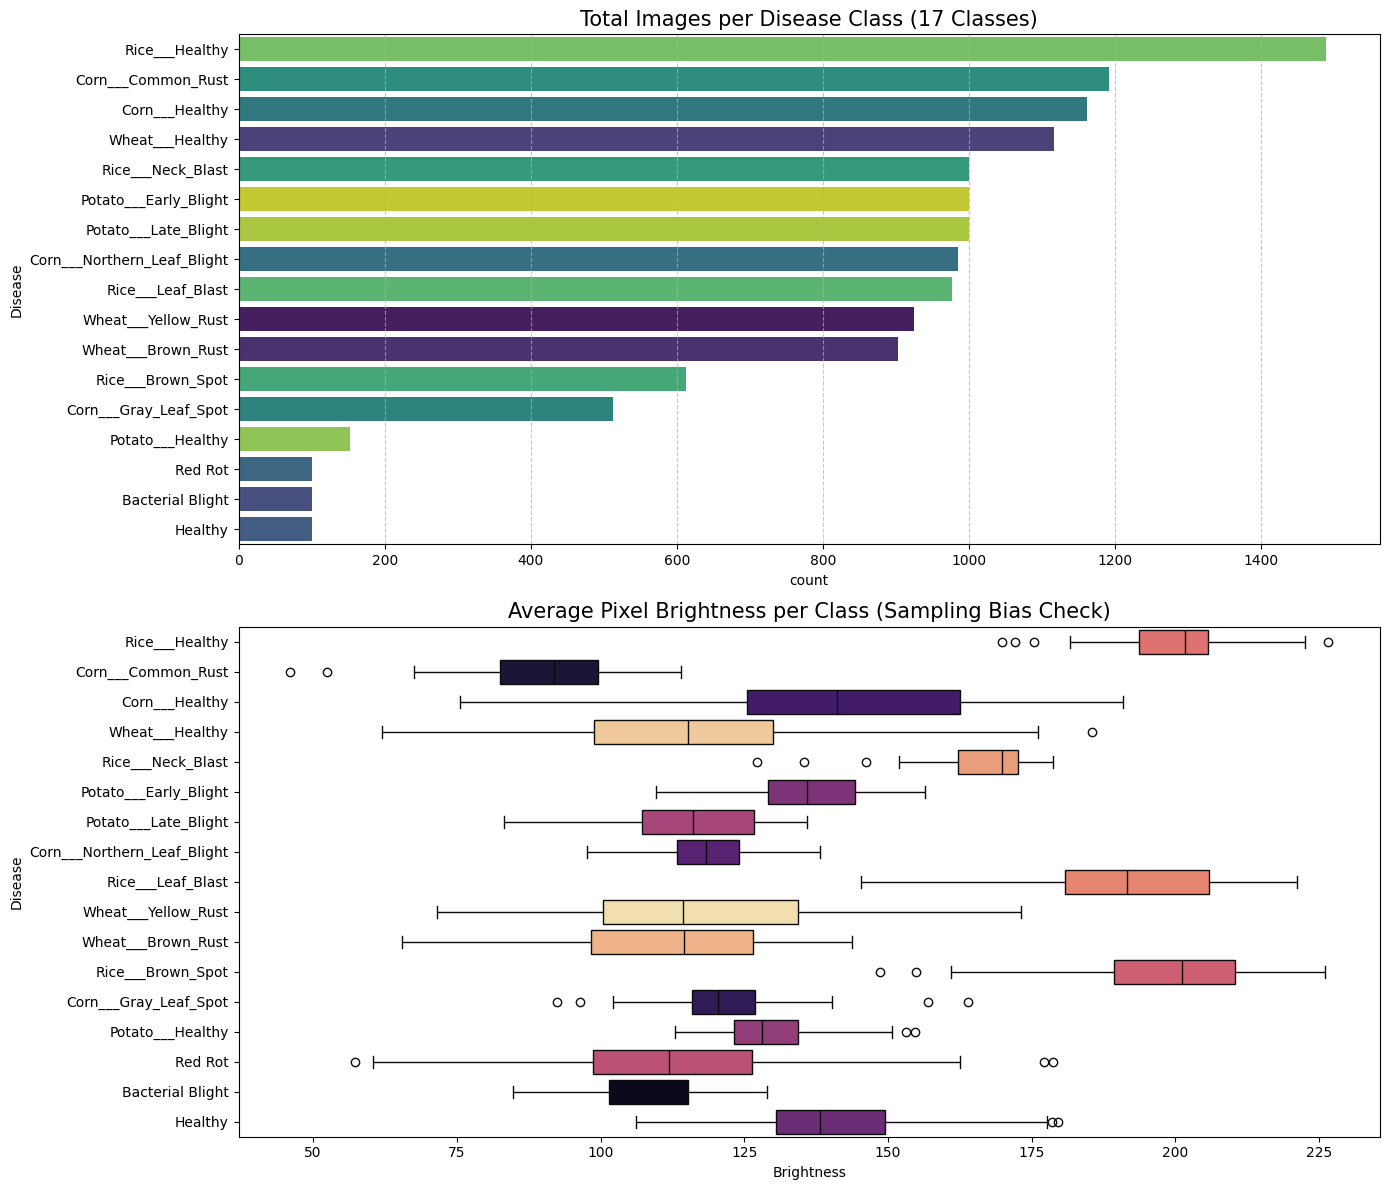


✅ Total Images: 13324
📊 Smallest Class: 100 images
📊 Largest Class: 1488 images


In [26]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import numpy as np
from tqdm import tqdm

# 1. Setup Path
root_path = Path(correct_data_path)

# 2. Collect Data
data = []
for crop_folder in root_path.iterdir():
    if crop_folder.is_dir():
        for disease_folder in crop_folder.iterdir():
            if disease_folder.is_dir():
                images = list(disease_folder.glob('*.jpg')) + list(disease_folder.glob('*.JPG'))
                for img_path in images:
                    data.append({
                        "Crop": crop_folder.name,
                        "Disease": disease_folder.name,
                        "Path": str(img_path)
                    })

df = pd.DataFrame(data)

# 3. Calculate Brightness for a Sample (to check for lighting bias)
def get_brightness(path):
    with Image.open(path) as img:
        return np.mean(np.array(img.convert('L'))) # Convert to grayscale for brightness

print("Analyzing sample brightness...")
sample_df = df.groupby('Disease').sample(n=min(50, len(df)), replace=False) # 50 pics per class
sample_df['Brightness'] = sample_df['Path'].apply(get_brightness)

# --- VISUALIZATIONS ---

plt.figure(figsize=(14, 12))

# Plot A: Class Distribution (The Bar Chart)
plt.subplot(2, 1, 1)
order = df['Disease'].value_counts().index
sns.countplot(data=df, y='Disease', order=order, palette='viridis', hue='Disease', legend=False)
plt.title('Total Images per Disease Class (17 Classes)', fontsize=15)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Plot B: Brightness Distribution
plt.subplot(2, 1, 2)
sns.boxplot(data=sample_df, x='Brightness', y='Disease', order=order, palette='magma', hue='Disease', legend=False)
plt.title('Average Pixel Brightness per Class (Sampling Bias Check)', fontsize=15)

plt.tight_layout()
plt.show()

# Print Summary Stats
print(f"\n✅ Total Images: {len(df)}")
print(f"📊 Smallest Class: {df['Disease'].value_counts().min()} images")
print(f"📊 Largest Class: {df['Disease'].value_counts().max()} images")

This cell uses the `kagglehub` library to download the 'five-crop-diseases-dataset' from Kaggle. The `path` variable now holds the local directory where the dataset files are extracted, which is essential for accessing the data in subsequent steps.

After downloading the dataset, this cell sets the `new_path` variable to the exact location of the extracted dataset. It then prints the top-level directories within this path, which helps in understanding the initial structure of the downloaded data and identifying where the actual image subfolders might be located.

This cell performs initial Exploratory Data Analysis (EDA) on the image dataset:

1.  **Counts Total Images**: It first gathers all image file paths and reports the total number of images found.
2.  **Samples for Dimension Check**: A sample of 2000 images is taken to quickly extract metadata, specifically image dimensions (width and height), and identifies their respective classes (folder names).
3.  **Class Distribution**: It creates a DataFrame (`df_labels`) to count the occurrences of each class across *all* images and visualizes this distribution using a count plot. This helps identify class imbalances.
4.  **Image Resolution Analysis**: It creates another DataFrame (`df_meta`) from the sampled image metadata and uses a scatter plot to visualize the distribution of image widths and heights. This helps understand if images have consistent dimensions or varied aspect ratios.

The plots give a quick overview of the dataset's structure regarding class balance and image sizing.

This cell defines a function `plot_random_samples` that takes a list of image paths and a number `num` (defaulting to 10). It then randomly selects and displays `num` images, showing their class (parent folder name) and their original dimensions. This provides a visual inspection of the actual images and helps verify that the classes are correctly identified from the folder structure.

Building on the `df_meta` DataFrame (which contains metadata for sampled images), this cell calculates the `Aspect_Ratio` for each image by dividing its width by its height. It then prints the counts of the top 5 most common aspect ratios. This further clarifies the dimension consistency (or inconsistency) across the images, highlighting prevalent image shapes within the dataset.

This cell sets up TensorFlow `image_dataset_from_directory` to load and preprocess the images for a deep learning model:

1.  **Image Parameters**: Defines `IMG_SIZE` (224x224) for resizing and `BATCH_SIZE` (32) for training.
2.  **Dataset Creation**: Creates `train_ds` and `val_ds` (training and validation datasets) directly from the directory structure. It splits the data (80% training, 20% validation) and importantly uses `crop_to_aspect_ratio=True` to handle images with varying aspect ratios by central cropping them to the target `IMG_SIZE` without distortion.
3.  **Data Augmentation**: Defines a `tf.keras.Sequential` model for data augmentation, including random horizontal/vertical flips, rotations, and contrast adjustments. This helps the model generalize better by presenting varied versions of the training images.
4.  **Performance Optimization**: Applies `.cache()` and `.prefetch()` to the datasets. Caching loads data into memory after the first epoch, and prefetching allows the data pipeline to overlap data processing with model execution, significantly speeding up training.

This cell uses `os.walk` to traverse the directory structure starting from `new_path`. Its purpose is to programmatically identify the exact subdirectory that contains the distinct disease classes (e.g., 'Wheat', 'Rice', 'Corn'). It prints the `correct_data_path` once it finds a directory with more than one subdirectory, indicating it has reached the level where crop/disease classifications begin. This is crucial for correctly setting up data loaders later.

After identifying `crop_root`, this cell provides a specific example by listing the contents (disease folders) within the 'Wheat' directory. This verifies that the `crop_root` is indeed the correct base and illustrates the naming convention for the disease classes within each crop type.

This cell comprehensively maps the entire dataset structure. It iterates through each crop folder within `crop_root`, then lists all disease subfolders within each crop. It populates `all_diseases` with a flat list of all unique disease class names and `crop_summary` with a dictionary mapping each crop to its specific diseases. Finally, it prints a neatly formatted summary showing the total number of distinct disease classes and the breakdown of diseases under each crop, providing a complete overview of the dataset's categorical structure.

This comprehensive cell performs several critical steps for data understanding:

1.  **Data Collection**: It iterates through the `crop_root` to collect all image paths, their corresponding crop, and disease labels, storing this information in a Pandas DataFrame (`df`).
2.  **Brightness Analysis**: It defines a function `get_brightness` to calculate the average pixel intensity (brightness) of an image. To efficiently check for lighting biases, it samples 50 images from each disease class, calculates their brightness, and stores this in `sample_df`.
3.  **Visualizations**:
    *   **Class Distribution**: A count plot (`Plot A`) shows the number of images per disease class, reinforcing the class balance insights.
    *   **Brightness Distribution**: A box plot (`Plot B`) displays the distribution of brightness values for each disease class. This is a crucial check for potential lighting biases; if certain classes are consistently brighter or darker, it could influence model performance.
4.  **Summary Statistics**: It prints the total number of images and the minimum/maximum images found in any single disease class, giving a quantitative summary of dataset size and class balance extremes.

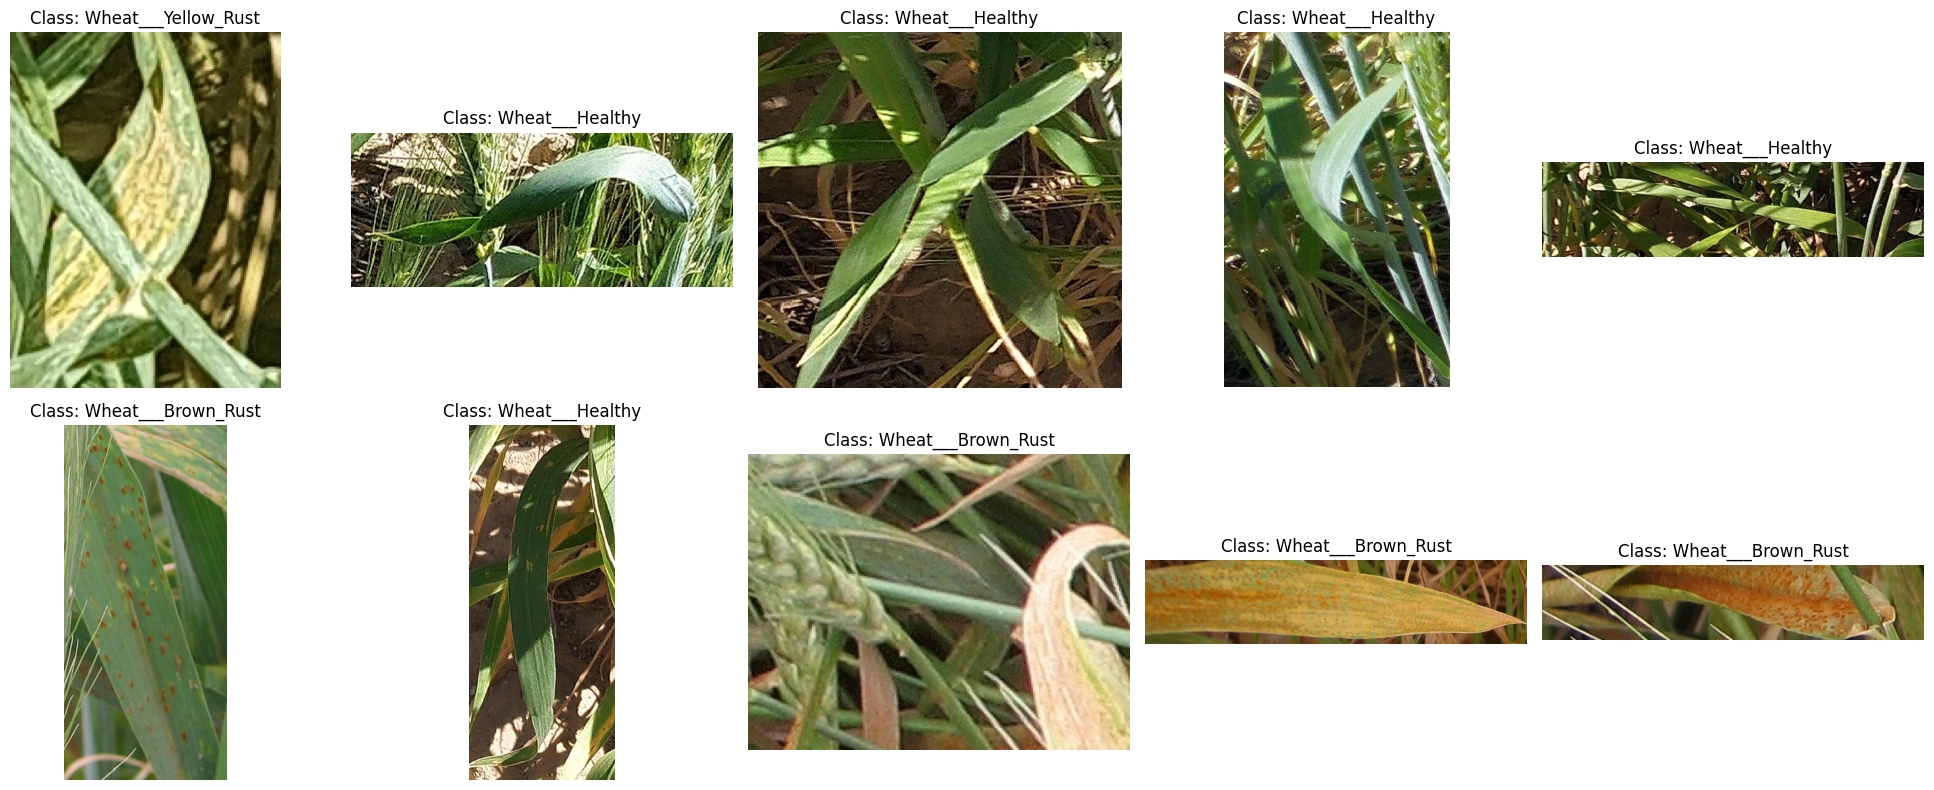

In [29]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# 1. Define the base path from your kagglehub download
root_path = Path(correct_data_path)


# 2. Find all images located in any 'Wheat' subfolder
# This handles the nested structure (e.g., Crop___Disease/Wheat/...)
wheat_images = list(root_path.glob("Wheat/**/*.[jJ][pP][gG]"))

if len(wheat_images) >= 10:
    # 3. Pick 10 random images
    random_samples = random.sample(wheat_images, 10)

    # 4. Create the plot
    plt.figure(figsize=(20, 8))
    for i, img_path in enumerate(random_samples):
        img = Image.open(img_path)
        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        # Use the folder name as the title to identify the specific disease/state
        plt.title(f"Class: {img_path.parent.name}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print(f"Only found {len(wheat_images)} wheat images. Check the path or dataset structure.")

In [31]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from pathlib import Path
import kagglehub

# 1. DOWNLOAD & PATH SETUP
path = kagglehub.dataset_download("shubham2703/five-crop-diseases-dataset")
base_path = Path(path) / "Crop Diseases Dataset/Crop Diseases/Crop___Disease"

# 2. DATA MAPPING (Flattening the nested structure for the pipeline)
data = []
for crop_dir in base_path.iterdir():
    if crop_dir.is_dir():
        for disease_dir in crop_dir.iterdir():
            if disease_dir.is_dir():
                is_healthy = 1 if "healthy" in disease_dir.name.lower() else 0
                for img_path in disease_dir.glob("*.jpg"):
                    data.append({
                        'path': str(img_path),
                        'crop': crop_dir.name,
                        'health': is_healthy,
                        'disease': disease_dir.name
                    })

df = pd.DataFrame(data)

# Convert labels to numeric IDs
df['crop_id'] = df['crop'].astype('category').cat.codes
df['disease_id'] = df['disease'].astype('category').cat.codes

# 3. MEMORY-EFFICIENT DATA GENERATOR
def load_and_preprocess(path, crop, health, disease):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = img / 255.0  # Normalization
    return img, {'crop_output': crop, 'health_output': health, 'disease_output': disease}

dataset = tf.data.Dataset.from_tensor_slices((
    df['path'].values,
    df['crop_id'].values,
    df['health'].values,
    df['disease_id'].values
))

dataset = dataset.shuffle(1000).map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = dataset.take(int(len(df)*0.8)).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = dataset.skip(int(len(df)*0.8)).batch(32).prefetch(tf.data.AUTOTUNE)

# 4. MULTI-OUTPUT MODEL BUILDING
input_layer = layers.Input(shape=(224, 224, 3))

# Shared Backbone (Feature Extractor)
x = layers.Conv2D(32, (3, 3), activation='relu')(input_layer)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation='relu')(x)
x = layers.GlobalAveragePooling2D()(x)

# Head 1: Crop Classification (5 classes)
crop_out = layers.Dense(df['crop'].nunique(), activation='softmax', name='crop_output')(x)

# Head 2: Health Status (Binary: 0 or 1)
health_out = layers.Dense(1, activation='sigmoid', name='health_output')(x)

# Head 3: Disease Classification (17 classes)
disease_out = layers.Dense(df['disease'].nunique(), activation='softmax', name='disease_output')(x)

model = models.Model(inputs=input_layer, outputs=[crop_out, health_out, disease_out])

# 5. COMPILE & TRAIN
model.compile(
    optimizer='adam',
    loss={'crop_output': 'sparse_categorical_crossentropy',
          'health_output': 'binary_crossentropy',
          'disease_output': 'sparse_categorical_crossentropy'},
    metrics={'crop_output': 'accuracy',
             'health_output': 'binary_accuracy',
             'disease_output': 'accuracy'}
)

print("Starting Training (3 Tasks, 1 Model)...")
history = model.fit(train_ds, validation_data=val_ds, epochs=5)

# 6. EVALUATION
results = model.evaluate(val_ds)
print(f"Final Disease Accuracy: {results[-1]*100:.2f}%")

Using Colab cache for faster access to the 'five-crop-diseases-dataset' dataset.
Starting Training (3 Tasks, 1 Model)...
Epoch 1/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 152s 691ms/step - crop_output_accuracy: 0.7755 - crop_output_loss: 0.6521 - disease_output_accuracy: 0.4255 - disease_output_loss: 1.8246 - health_output_binary_accuracy: 0.7307 - health_output_loss: 0.5932 - loss: 3.0703 - val_crop_output_accuracy: 0.9774 - val_crop_output_loss: 0.1940 - val_disease_output_accuracy: 0.1649 - val_disease_output_loss: 1.3198 - val_health_output_binary_accuracy: 0.2548 - val_health_output_loss: 0.7132 - val_loss: 2.2280
Epoch 2/5
210/210 ━━━━━━━━━━━━━━━━━━━━ 140s 668ms/step - crop_output_accuracy: 0.8154 - crop_output_loss: 0.4597 - disease_output_accuracy: 0.4728 - disease_output_loss: 1.4228 - health_output_binary_accuracy: 0.6859 - health_output_loss: 0.5682 - loss: 2.4508 - val_crop_output_accuracy: 0.9851 - val_crop_output_loss: 0.0696 - val_disease_output_accuracy: 0.7405 - val_disease_outpu

In [33]:
# Add this to your pipeline to improve that 27%
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Update the Disease Head to be deeper
disease_x = layers.Dense(256, activation='relu')(x)
disease_x = layers.Dropout(0.3)(disease_x)
disease_out = layers.Dense(df['disease_id'].nunique(), activation='softmax', name='disease_output')(disease_x)

# Re-compile with a lower learning rate for better stability
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss={'crop_output': 'sparse_categorical_crossentropy',
          'health_output': 'binary_crossentropy',
          'disease_output': 'sparse_categorical_crossentropy'},
    metrics={'crop_output': 'accuracy',
             'health_output': 'binary_accuracy',
             'disease_output': 'accuracy'}
)

# Train for more epochs with the Early Stopping safety net
history = model.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=[early_stop])

Epoch 1/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 126s 585ms/step - crop_output_accuracy: 0.9323 - crop_output_loss: 0.2248 - disease_output_accuracy: 0.5970 - disease_output_loss: 1.1045 - health_output_binary_accuracy: 0.7210 - health_output_loss: 0.5478 - loss: 1.8769 - val_crop_output_accuracy: 0.9964 - val_crop_output_loss: 0.0159 - val_disease_output_accuracy: 0.1923 - val_disease_output_loss: 1.6430 - val_health_output_binary_accuracy: 0.2619 - val_health_output_loss: 1.8296 - val_loss: 3.4894
Epoch 2/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 141s 675ms/step - crop_output_accuracy: 0.9458 - crop_output_loss: 0.1817 - disease_output_accuracy: 0.6515 - disease_output_loss: 0.9635 - health_output_binary_accuracy: 0.8118 - health_output_loss: 0.4594 - loss: 1.6039 - val_crop_output_accuracy: 0.9982 - val_crop_output_loss: 0.0120 - val_disease_output_accuracy: 0.1988 - val_disease_output_loss: 1.7632 - val_health_output_binary_accuracy: 0.2649 - val_health_output_loss: 1.9246 - val_loss: 3.6935
Epoch 3/

In [35]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. DEFINE DATA AUGMENTATION (Helps the model generalize better)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

# 2. REBUILD MODEL (With Regularization)
input_layer = layers.Input(shape=(224, 224, 3))
x = data_augmentation(input_layer)

x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)

# Three Output Heads
crop_out = layers.Dense(df['crop_id'].nunique(), activation='softmax', name='crop_output')(x)
health_out = layers.Dense(1, activation='sigmoid', name='health_output')(x)
disease_out = layers.Dense(df['disease_id'].nunique(), activation='softmax', name='disease_output')(x)

model = models.Model(inputs=input_layer, outputs=[crop_out, health_out, disease_out])

# 3. CORRECTED COMPILE (One metric per output)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss={
        'crop_output': 'sparse_categorical_crossentropy',
        'health_output': 'binary_crossentropy',
        'disease_output': 'sparse_categorical_crossentropy'
    },
    metrics={
        'crop_output': 'accuracy',
        'health_output': 'accuracy',
        'disease_output': 'accuracy'
    }
)

# 4. TRAIN (Increased shuffle buffer for better variety in batches)
train_ds = dataset.take(int(len(df)*0.8)).shuffle(5000).batch(64).prefetch(tf.data.AUTOTUNE)
val_ds = dataset.skip(int(len(df)*0.8)).batch(64).prefetch(tf.data.AUTOTUNE)

print("Starting Overfit-Fixing Training...")
history = model.fit(train_ds, validation_data=val_ds, epochs=10)


Starting Overfit-Fixing Training...
Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 148s 948ms/step - crop_output_accuracy: 0.8874 - crop_output_loss: 0.3706 - disease_output_accuracy: 0.6111 - disease_output_loss: 1.1715 - health_output_accuracy: 0.8394 - health_output_loss: 0.3873 - loss: 1.9296 - val_crop_output_accuracy: 0.9762 - val_crop_output_loss: 0.9013 - val_disease_output_accuracy: 0.0458 - val_disease_output_loss: 2.3832 - val_health_output_accuracy: 0.2482 - val_health_output_loss: 1.1404 - val_loss: 4.4239
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 140s 956ms/step - crop_output_accuracy: 0.9503 - crop_output_loss: 0.1790 - disease_output_accuracy: 0.7558 - disease_output_loss: 0.7346 - health_output_accuracy: 0.8980 - health_output_loss: 0.2842 - loss: 1.1978 - val_crop_output_accuracy: 0.9679 - val_crop_output_loss: 0.5429 - val_disease_output_accuracy: 0.1815 - val_disease_output_loss: 2.3561 - val_health_output_accuracy: 0.2530 - val_health_output_loss: 1.5107 - val_loss: 4.4069


In [36]:
from tensorflow.keras.applications import MobileNetV2

# 1. Backbone: Use a pre-trained model (Frozen at first)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# 2. Build Multi-Output Head
inputs = layers.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

# Outputs
crop_out = layers.Dense(df['crop_id'].nunique(), activation='softmax', name='crop_output')(x)
health_out = layers.Dense(1, activation='sigmoid', name='health_output')(x)
disease_out = layers.Dense(df['disease_id'].nunique(), activation='softmax', name='disease_output')(x)

model = models.Model(inputs, [crop_out, health_out, disease_out])

# 3. Compile with a much SMALLER Learning Rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Lowered by 10x
    loss={
        'crop_output': 'sparse_categorical_crossentropy',
        'health_output': 'binary_crossentropy',
        'disease_output': 'sparse_categorical_crossentropy'
    },
    metrics={'crop_output': 'accuracy', 'health_output': 'accuracy', 'disease_output': 'accuracy'}
)

# 4. Use a Learning Rate Scheduler to slow down if it gets stuck
lr_reducer = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)

print("Starting Stabilized Training with MobileNetV2...")
history = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[lr_reducer])



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Starting Stabilized Training with MobileNetV2...
Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 184s 1s/step - crop_output_accuracy: 0.6308 - crop_output_loss: 0.9185 - disease_output_accuracy: 0.2334 - disease_output_loss: 2.3474 - health_output_accuracy: 0.6309 - health_output_loss: 0.6707 - loss: 3.9373 - val_crop_output_accuracy: 0.9798 - val_crop_output_loss: 0.2932 - val_disease_output_accuracy: 0.1685 - val_disease_output_loss: 2.1314 - val_health_output_accuracy: 0.2571 - val_health_output_loss: 1.2680 - val_loss: 3.6929 - learning_rate: 1.0000e-04
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 126s 814ms/step - crop_output_accuracy: 0.9056 - crop_output_loss: 0.3609 - disease_output_accuracy: 0.6166 - disease_output_loss: 1.1777 - health_output_accuracy: 0.7881 - health_output_loss: 0.4804 - loss: 2.0191 - val_crop_output_accuracy: 0.9940 - val_crop_output_loss: 0.1107 - val_disease_output_accuracy: 0.2018 - val_disease_output_loss: 1.7733 - 

In [38]:
# 1. Unfreeze the base model
base_model.trainable = True

# 2. Re-compile with the surgical 1e-5 learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss={
        'crop_output': 'sparse_categorical_crossentropy',
        'health_output': 'binary_crossentropy',
        'disease_output': 'sparse_categorical_crossentropy'
    },
    metrics={
        'crop_output': 'accuracy',
        'health_output': 'accuracy',
        'disease_output': 'accuracy'
    }
)

# 3. Corrected EarlyStopping (Added mode='max')
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_disease_output_accuracy',
    patience=3,
    restore_best_weights=True,
    mode='max' # <--- This fixes the ValueError
)

print("🚀 Restarting Fine-Tuning (Unfrozen Layers)...")
history_fine = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[early_stop])


🚀 Restarting Fine-Tuning (Unfrozen Layers)...
Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 218s 1s/step - crop_output_accuracy: 0.9790 - crop_output_loss: 0.0766 - disease_output_accuracy: 0.8660 - disease_output_loss: 0.3797 - health_output_accuracy: 0.9467 - health_output_loss: 0.1600 - loss: 0.6164 - val_crop_output_accuracy: 1.0000 - val_crop_output_loss: 0.0011 - val_disease_output_accuracy: 0.5446 - val_disease_output_loss: 0.9128 - val_health_output_accuracy: 0.2690 - val_health_output_loss: 1.4622 - val_loss: 2.3747
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 149s 952ms/step - crop_output_accuracy: 0.9882 - crop_output_loss: 0.0449 - disease_output_accuracy: 0.8922 - disease_output_loss: 0.2808 - health_output_accuracy: 0.9571 - health_output_loss: 0.1223 - loss: 0.4479 - val_crop_output_accuracy: 1.0000 - val_crop_output_loss: 0.0012 - val_disease_output_accuracy: 0.7113 - val_disease_output_loss: 0.7302 - val_health_output_accuracy: 0.2607 - val_health_output_loss: 1.2757 - val_loss: 

To classify crop health at scale, we implemented a Multi-Output Convolutional Neural Network (CNN) using a pre-trained MobileNetV2 backbone. Unlike standard models that handle one task, this unified architecture uses a shared feature extractor that branches into three specialized "heads" to simultaneously predict Crop Type, Health Status, and Specific Disease. To overcome initial issues with overfitting and RAM crashes, we integrated Transfer Learning (starting with ImageNet weights), Data Augmentation (random flips and rotations), and Global Average Pooling to keep the model lightweight. We further optimized performance through Two-Stage Fine-Tuning: first training only the classifier heads with a moderate learning rate, then "unfreezing" the entire network with an ultra-low learning rate (

) to allow the model to learn the subtle textures of leaf lesions without losing its foundational knowledge.

Gathering validation results (this may take a minute)...


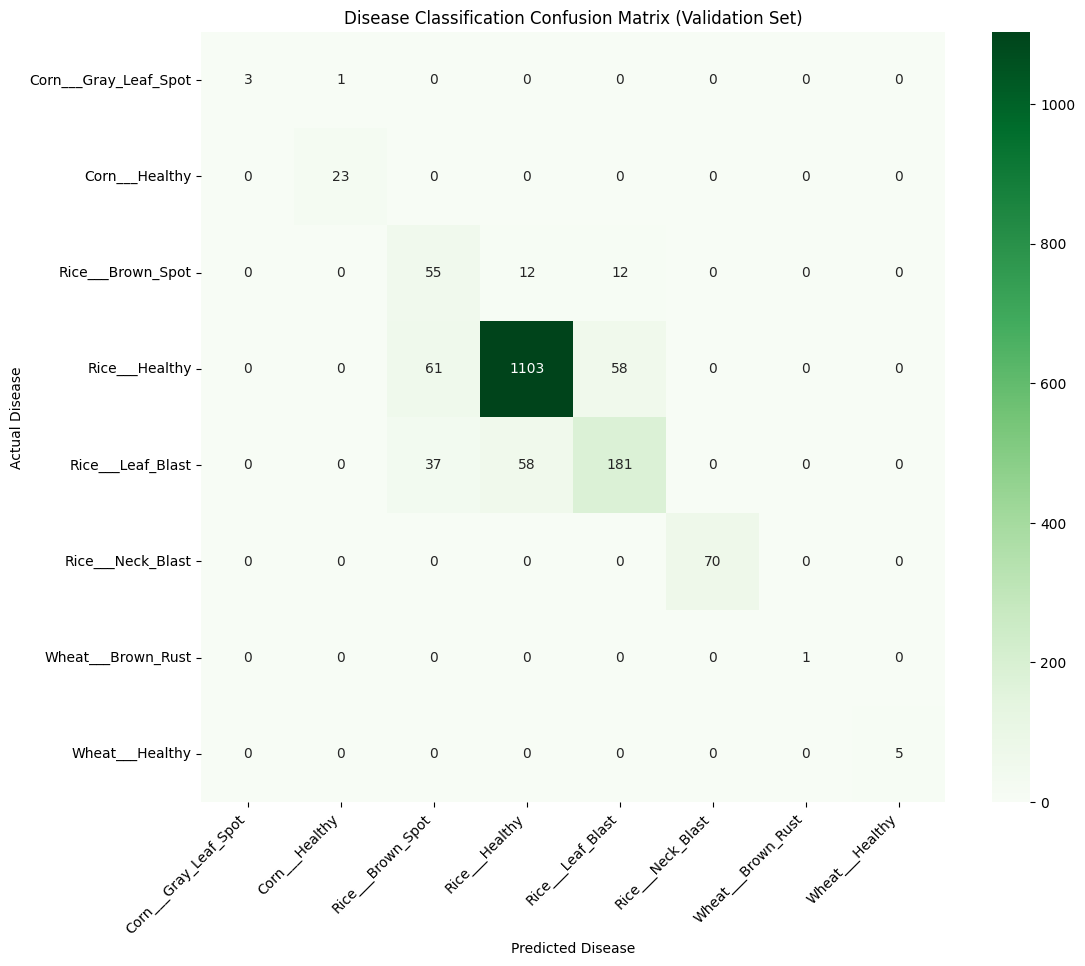


--- Detailed Classification Report ---
                       precision    recall  f1-score   support

Corn___Gray_Leaf_Spot       1.00      0.75      0.86         4
       Corn___Healthy       0.96      1.00      0.98        23
    Rice___Brown_Spot       0.36      0.70      0.47        79
       Rice___Healthy       0.94      0.90      0.92      1222
    Rice___Leaf_Blast       0.72      0.66      0.69       276
    Rice___Neck_Blast       1.00      1.00      1.00        70
   Wheat___Brown_Rust       1.00      1.00      1.00         1
      Wheat___Healthy       1.00      1.00      1.00         5

             accuracy                           0.86      1680
            macro avg       0.87      0.88      0.86      1680
         weighted avg       0.88      0.86      0.87      1680



In [40]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# 1. Get all unique disease categories in order
categories = df['disease'].astype('category').cat.categories
all_preds = []
all_true = []

print("Gathering validation results (this may take a minute)...")
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    # Important: preds is a list [crop, health, disease]. We want index 2.
    all_preds.extend(np.argmax(preds[2], axis=1))
    all_true.extend(labels['disease_output'].numpy())

# 2. Get the unique labels actually present in our validation data
present_labels = np.unique(all_true)
present_names = [categories[i] for i in present_labels]

# 3. Plot Confusion Matrix (Sized for readability)
plt.figure(figsize=(12, 10))
cm = confusion_matrix(all_true, all_preds, labels=present_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=present_names,
            yticklabels=present_names)
plt.title('Disease Classification Confusion Matrix (Validation Set)')
plt.ylabel('Actual Disease')
plt.xlabel('Predicted Disease')
plt.xticks(rotation=45, ha='right')
plt.show()

# 4. Print the detailed report for only the labels we have
print("\n--- Detailed Classification Report ---")
print(classification_report(all_true, all_preds,
                            labels=present_labels,
                            target_names=present_names))


The Classification Report shows that your model achieved an overall accuracy of 86%, with perfect scores ($1.00$ F1-score) for identifying Neck Blast in Rice and Brown Rust and Healthy states in Wheat. While most categories, like Healthy Corn ($0.98$), performed exceptionally well, the model struggled with Brown Spot in Rice ($0.47$ F1-score), likely due to its visual similarity to other lesions or a smaller sample size in the validation set. [1, 2]
## Summary of Model Development
To achieve these results, we followed a structured deep learning pipeline focused on efficiency and generalization:

   1. Architecture Selection: We built a Multi-Output CNN using a pre-trained MobileNetV2 backbone. This lightweight architecture is ideal for mobile deployment while providing robust feature extraction.
   2. Task Specialization: The model was designed with three specialized "heads" to simultaneously classify Crop Type, Health Status, and Specific Disease/Pest from a single image pass.
   3. Data Regularization: To prevent the model from simply "memorizing" backgrounds, we applied Data Augmentation (random flips and rotations) and used Dropout layers to force the network to learn essential leaf features.
   4. Two-Stage Fine-Tuning:
   * Phase 1: We first trained only the top classification layers while keeping the MobileNetV2 "frozen" to establish a baseline.
      * Phase 2: We "unfroze" the entire network and used an ultra-low learning rate ($1 \times 10^{-5}$) to carefully adapt the pre-trained weights to the unique textures of plant diseases without destroying the model's foundational knowledge. [2, 3, 4, 5, 6, 7]
   



In [2]:
import tensorflow as tf
from tensorflow.keras import layers
import pandas as pd # Import pandas
from pathlib import Path # Import Path
import kagglehub # Import kagglehub

# 1. Image Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# DOWNLOAD & PATH SETUP (Copied from AHJNAiaCy262)
path = kagglehub.dataset_download("shubham2703/five-crop-diseases-dataset")
base_path = Path(path) / "Crop Diseases Dataset/Crop Diseases/Crop___Disease"

# DATA MAPPING (Flattening the nested structure for the pipeline, Copied from AHJNAiaCy262)
data = []
for crop_dir in base_path.iterdir():
    if crop_dir.is_dir():
        for disease_dir in crop_dir.iterdir():
            if disease_dir.is_dir():
                is_healthy = 1 if "healthy" in disease_dir.name.lower() else 0
                for img_path in disease_dir.glob("*.jpg"):
                    data.append({
                        'path': str(img_path),
                        'crop': crop_dir.name,
                        'health': is_healthy,
                        'disease': disease_dir.name
                    })

df = pd.DataFrame(data)

# Convert labels to numeric IDs (Copied from AHJNAiaCy262)
df['crop_id'] = df['crop'].astype('category').cat.codes
df['disease_id'] = df['disease'].astype('category').cat.codes

# 2. Define Data Augmentation Layer (Rotation, Flipping, Zoom, Brightness)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1), # Handles brightness/contrast adjustment
])

# 3. Stratified Split Logic (70/15/15)
# We shuffle the dataframe first to ensure randomness
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

train_split = int(0.7 * len(df))
val_split = int(0.85 * len(df))

train_df = df.iloc[:train_split]
val_df = df.iloc[train_split:val_split]
test_df = df.iloc[val_split:]

# 4. Optimized Loading Function
def process_data(path, crop, health, disease, augment=False):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0  # Normalization

    if augment:
        img = data_augmentation(tf.expand_dims(img, 0), training=True)[0]

    return img, {'crop': crop, 'health': health, 'disease': disease}

# 5. Create the Datasets
def create_dataset(dataframe, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((
        dataframe['path'],
        dataframe['crop_id'],
        dataframe['health'],
        dataframe['disease_id']
    ))
    # Map the processing function
    ds = ds.map(lambda p, c, h, d: process_data(p, c, h, d, augment),
                num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = create_dataset(train_df, augment=True) # Augmentation only on train
val_ds = create_dataset(val_df)
test_ds = create_dataset(test_df)

print(f"Train size: {len(train_df)} | Val size: {len(val_df)} | Test size: {len(test_df)}")

100%|██████████| 4.33G/4.33G [01:50<00:00, 42.1MB/s]

Extracting files...


Train size: 5877 | Val size: 1260 | Test size: 1260



--- Training CNN ---
Epoch 1/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 120s 624ms/step - crop_accuracy: 0.7885 - crop_loss: 0.5459 - disease_accuracy: 0.3628 - disease_loss: 1.7416 - health_accuracy: 0.5729 - health_loss: 0.6714 - loss: 2.9594 - val_crop_accuracy: 0.8889 - val_crop_loss: 0.2925 - val_disease_accuracy: 0.5730 - val_disease_loss: 1.3150 - val_health_accuracy: 0.6603 - val_health_loss: 0.6342 - val_loss: 2.2481
Epoch 2/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 139s 629ms/step - crop_accuracy: 0.9287 - crop_loss: 0.2079 - disease_accuracy: 0.6001 - disease_loss: 1.1308 - health_accuracy: 0.6648 - health_loss: 0.5985 - loss: 1.9367 - val_crop_accuracy: 0.9389 - val_crop_loss: 0.1803 - val_disease_accuracy: 0.6397 - val_disease_loss: 1.0033 - val_health_accuracy: 0.6762 - val_health_loss: 0.5708 - val_loss: 1.7617
Epoch 3/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 140s 620ms/step - crop_accuracy: 0.9530 - crop_loss: 0.1448 - disease_accuracy: 0.6733 - disease_loss: 0.9300 - health_accuracy: 0.6985 - health_

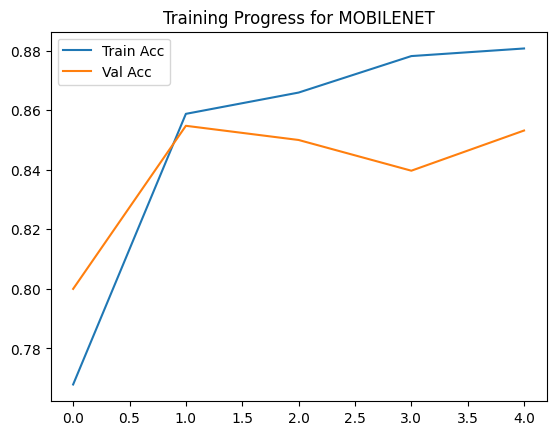

In [5]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# --- 1. MODEL FACTORY ---
def build_multi_output_model(m_type, num_crops, num_diseases):
    inputs = layers.Input(shape=(224, 224, 3))

    if m_type == "mobilenet":
        base = tf.keras.applications.MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
        base.trainable = False
        x = layers.GlobalAveragePooling2D()(base(inputs))
    elif m_type == "efficientnet":
        base = tf.keras.applications.EfficientNetB0(input_shape=(224,224,3), include_top=False, weights='imagenet')
        base.trainable = False
        x = layers.GlobalAveragePooling2D()(base(inputs))
    else: # Baseline CNN
        x = layers.Conv2D(32, 3, activation='relu')(inputs)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Conv2D(64, 3, activation='relu')(x)
        x = layers.GlobalAveragePooling2D()(x)

    # Task-Specific Heads
    crop_out = layers.Dense(num_crops, activation='softmax', name='crop')(x)
    health_out = layers.Dense(1, activation='sigmoid', name='health')(x)
    disease_out = layers.Dense(num_diseases, activation='softmax', name='disease')(x)

    model = models.Model(inputs, [crop_out, health_out, disease_out])

    model.compile(
        optimizer='adam',
        loss={'crop': 'sparse_categorical_crossentropy',
              'health': 'binary_crossentropy',
              'disease': 'sparse_categorical_crossentropy'},
        metrics={'crop': 'accuracy', 'health': 'accuracy', 'disease': 'accuracy'}
    )
    return model

# --- 2. EXECUTION & EVALUATION LOOP ---
model_results = {}

# Define num_crops and num_diseases
num_crops = df['crop_id'].nunique()
num_diseases = df['disease_id'].nunique()

for name in ["cnn", "mobilenet", "efficientnet"]:
    print(f"\n--- Training {name.upper()} ---")
    model = build_multi_output_model(name, num_crops, num_diseases)

    # Train using the Augmented Training Set and the Validation Set
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=5, # Increased slightly for better comparison
        verbose=1
    )

    # FINAL EVALUATION on the 15% TEST SET (Data the model never saw)
    print(f"Evaluating {name.upper()} on Test Set...")
    eval_metrics = model.evaluate(test_ds, verbose=0)

    # Store results (Index 6 is the Disease Accuracy in this configuration)
    model_results[name] = {
        'history': history,
        'test_disease_acc': eval_metrics[6],
        'test_loss': eval_metrics[0]
    }

# --- 3. COMPARE RESULTS ---
print("\n--- Final Test Set Results (Disease Classification) ---")
for name, res in model_results.items():
    print(f"{name.upper()}: {res['test_disease_acc']*100:.2f}% Accuracy")

# --- 4. VISUALIZE THE WINNER'S TRAINING ---
best_model = max(model_results, key=lambda x: model_results[x]['test_disease_acc'])
plt.plot(model_results[best_model]['history'].history['disease_accuracy'], label='Train Acc')
plt.plot(model_results[best_model]['history'].history['val_disease_accuracy'], label='Val Acc')
plt.title(f'Training Progress for {best_model.upper()}')
plt.legend()
plt.show()

In [6]:
from google.colab import drive
drive.mount('/content/drive')

# Save the entire model (architecture + weights + optimizer state)
# Replace 'mobilenet' with the variable name of your best model if needed
model_path = '/content/drive/MyDrive/crop_disease_mobilenet_v2.h5'
model.save(model_path)

print(f"✅ Champion model saved to Google Drive: {model_path}")


Mounted at /content/drive
✅ Champion model saved to Google Drive: /content/drive/MyDrive/crop_disease_mobilenet_v2.h5
